In [ ]:

'''

GUILHERME LIMA DE SOUSA - 
ESTUDO DE CASO: TONELADAS TRANSPORTADAS EM FERROVIAS BRASILEIRAS
OBJETIVO: CLUSTERIZAÇÃO USANDO KMEANS

ENTRE EM CONTATO COMIGO NO LINKEDIN: 
www.linkedin.com/in/guilherme-lima-747355169

'''


import pandas as pd
import numpy as np
import glob
import os
import matplotlib.pyplot as plt
import seaborn as sns
from numpy import random
import mlflow


################################################################################


# ETL DA BASE

################################################################################



##CONFIGURANDO NUMEROS COM 2 CASAS DECIMAIS
pd.set_option('Float_format','{:.2f}'.format)

## COMPILANDO ARQUIVOS DA PASTA
pasta = 'C:/Users/Guilh/OneDrive/Área de Trabalho/1-MATERIAIS DE ESTUDO/01 - DIVERSOS/01-SCIKIT_LEARN/01-INPUT'
arquivos = glob.glob(os.path.join(pasta, '*.csv'))
base_original = pd.concat([pd.read_csv(i, sep=';', encoding='latin1') for i in arquivos], ignore_index = True)

## REMOVENDO PONTO DA COLUNA
base_original['TU'] = base_original['TU'].str.replace('.','',regex=False)
base_original['TKU'] = base_original['TKU'].str.replace('.','',regex=False)

## ALTERANDO FORMATAÇÃO DA COLUNA
base_original['TKU'] = base_original['TKU'].fillna(0)
base_original['TKU'] = base_original['TKU'].astype(float)
base_original['TU'] = base_original['TU'].astype(int)
base_original['TKU'] = base_original['TKU'].astype(int)
base_original['Mes_Ano'] = pd.to_datetime(base_original['Mes_Ano'], format='%m/%Y')

## CRIANDO COLUNAS
base_original['MÊS'] = base_original['Mes_Ano'].dt.month
base_original['ANO'] = base_original['Mes_Ano'].dt.year

#REMOVENDO DUPLICADOS E NULOS
base_original = base_original.drop_duplicates()

# REMOVENDO COLUNA TKU POIS O OBJETIVO É APNAS TU
base_original = base_original.drop('TKU', axis=1)
base_original = base_original.drop('Mes_Ano', axis=1)

# REMOVENDO VALORES ABAIXO DE 1 TONELADA
base_original = base_original[base_original["TU"]>= 1]

# VENDO A BASE
base_original.head(-5)

,Ferrovia,Mercadoria_ANTT,Estacao_Origem,UF_Origem,Estacao_Destino,UF_Destino,TU,MÊS,ANO
0,EFC,Álcool,Itaqui Base Combustível,MA,Marabá,PA,184,1,2006
1,EFC,Bebidas e Vasilhames,Ponta da Madeira Pêra do Píer,MA,Imperatriz,MA,1636,1,2006
2,EFC,Cobre,Paraupebas,PA,Ponta da Madeira Cobre,MA,24461,1,2006
3,EFC,Ferro Gusa,Açailândia,MA,Ponta da Madeira Pêra do Píer,MA,116272,1,2006
4,EFC,Ferro Gusa,Marabá,PA,Ponta da Madeira Pêra do Píer,MA,205242,1,2006
...,...,...,...,...,...,...,...,...,...
148653,RMS,Soja,Marialva,PR,D Pedro II,PR,179173,4,2023
148654,RMS,Soja,Marialva,PR,São Francisco do Sul,SC,80527,4,2023
148655,RMS,Soja,Maringa,PR,D Pedro II,PR,193917,4,2023
148656,RMS,Soja,Maringa,PR,Rio Grande,RS,1710,4,2023


In [59]:


####################################################################################

#     CRIANDO DATASET DO MODELO

####################################################################################

'''

AQUI VAMOS CRIAR O DATASET DO MODELO
FAZENDO ETL COM AS COLUNAS CATEGORICAS E APLICANDO CÓDIGOS PARA CADA UMA, 
POSTERIORMENTE USANDO AS COLUNAS NUMERICAS REPRESENTADAS COMO VARIAVEIS DO MODELO.
EM VEZ DE USAR O NOME DA FERROVIA ESTAMOS CRIANDO UM CÓDIGO DISTINTO DELA.

'''


# REPRODUTIBILIDADE
np.random.seed(2)


## BASE MODELO
#print(base_original.columns)
print('--------------------')
base_modelo = base_original

# TRANSFORMANDO COLUNAS
base_modelo['ANO'] = base_modelo['ANO'].astype(int)
base_modelo['MÊS'] = base_modelo['MÊS'].astype(int)
base_modelo['TU'] = base_modelo['TU'].astype(int)

#
############### CRIANDO OS CÓDIGOS DE CADA CATEGORIA
# SELECIONA APENAS AS COLUNAS STRING/CATEGORIAS/OBJETO
categ = base_modelo.select_dtypes(include=['object', 'category']).copy()
# LAMBDA QUE TRANSFORMA AS COLUNAS E NUMEROS
cod_categorica_hoje_1 = categ.apply(lambda col: col.astype('category').cat.codes)
# RENOMEANDO AS COLUNAS DE CODIGO COM PREFIXO
cod_categorica_1 = cod_categorica_hoje_1.add_prefix('Codigo_')


# CONCATENANDO AS BASES DE CODIGOS COM A ORIGINAL
codigos_categorias = pd.concat([base_modelo, cod_categorica_1], axis=1)

print('################# BASE COM DE:PARA ########################\n')
# BASE COM TUDO
codigos_categorias[(codigos_categorias['Codigo_Mercadoria_ANTT']==11) & (codigos_categorias['Codigo_Estacao_Origem']==316) 
                   & (codigos_categorias['Codigo_Mercadoria_ANTT']==11) & (codigos_categorias['ANO']==2006) & (codigos_categorias['MÊS']==1)].head(3)


##########  PARA VISUALIZAR DE:PARA DE COLUNA ESPECIFICA
#visualizar_de_para = codigos_categorias[['Ferrovia', 'Codigo_Ferrovia']].drop_duplicates().reset_index(drop=True)
#print('\n################# VERIFICAR ########################\n')
#print(visualizar_de_para.head(3))



--------------------
################# BASE COM DE:PARA ########################



,Ferrovia,Mercadoria_ANTT,Estacao_Origem,UF_Origem,Estacao_Destino,UF_Destino,TU,MÊS,ANO,Codigo_Ferrovia,Codigo_Mercadoria_ANTT,Codigo_Estacao_Origem,Codigo_UF_Origem,Codigo_Estacao_Destino,Codigo_UF_Destino
1,EFC,Bebidas e Vasilhames,Ponta da Madeira Pêra do Píer,MA,Imperatriz,MA,1636,1,2006,0,11,316,5,187,5


In [60]:
####################################################################################

#     TRANSFORMANDO DATASET DO MODELO KMEANS

####################################################################################

''' 
AQUI ESTOU REMOVENDO OS VALORES MENORES DE 1000 MIL TONELADAS DE MOVIMENTAÇÃO
POIS ABAIXO DE MIL DEIXA O MODELO RUIM, MUITO COMPLEXO PRA ENTENDER OS DADOS
QUE VARIAM DE ZERO A MILHOES.

'''
# CRIANDO A BASE
base_treino = codigos_categorias.select_dtypes(exclude=['object', 'category']).copy()

#REMOVENDO DUPLICADOS
base_treino = base_treino.drop_duplicates()
base_treino = base_treino.fillna(0)

# SALVANDO BASE DO MODELO COMPLETA SEM FILTROS
base_modelo_completa = base_treino

# LIMITANDO A BASE REMOVENDO 2023
base_treino = base_treino[base_treino['ANO'] != 2023][list(base_treino.columns)]


# REMOVENDO OS OUTLIERS - TUDO QUE É MENOR DE MIL TONELADAS
base_treino = base_treino[base_treino['TU'] >= 1000.00]
base_modelo = base_treino


# REMOVENDO OS OUTLIERS - TUDO QUE ESTÁ MAIOR DO 3º QUARTIL EM TONELADAS
#q3 = base_treino['TU'].quantile(0.75)
#base_treino = base_treino[base_treino['TU'] <= q3]
#base_modelo = base_treino



# LOGARITMO BASE10
base_modelo['TU_LOG10'] = np.log10(base_modelo['TU'])


# REMOVENDO COLUNA REAL
base_modelo = base_modelo.drop('TU', axis=1)


base_modelo = base_modelo[["MÊS", "ANO", "Codigo_Ferrovia", "Codigo_Mercadoria_ANTT",
                          "Codigo_Estacao_Origem", "Codigo_UF_Origem", "Codigo_Estacao_Destino",
                          "Codigo_UF_Destino", "TU_LOG10"]]


print('################# BASE MODELO ########################')
print(base_modelo.head(3))
base_modelo.describe()


################# BASE MODELO ########################
   MÊS   ANO  Codigo_Ferrovia  Codigo_Mercadoria_ANTT  Codigo_Estacao_Origem  \
1    1  2006                0                      11                    316   
2    1  2006                0                      22                    293   
3    1  2006                0                      44                     36   

   Codigo_UF_Origem  Codigo_Estacao_Destino  Codigo_UF_Destino  TU_LOG10  
1                 5                     187                  5      3.21  
2                 9                     296                  5      4.39  
3                 5                     297                  5      5.07  


,MÊS,ANO,Codigo_Ferrovia,Codigo_Mercadoria_ANTT,Codigo_Estacao_Origem,Codigo_UF_Origem,Codigo_Estacao_Destino,Codigo_UF_Destino,TU_LOG10
count,109216.00,109216.00,109216.00,109216.00,109216.00,109216.00,109216.00,109216.00,109216.00
mean,6.55,2013.46,6.90,53.71,234.52,10.26,224.13,11.75,4.03
std,3.43,5.00,3.92,30.10,127.57,5.37,121.22,5.59,0.68
min,1.00,2006.00,0.00,0.00,1.00,0.00,0.00,0.00,3.00
25%,4.00,2009.00,3.00,23.00,132.00,6.00,127.00,6.00,3.51
50%,7.00,2013.00,7.00,59.00,247.00,9.00,233.00,13.00,3.92
75%,10.00,2018.00,12.00,81.00,341.00,15.00,340.00,18.00,4.42
max,12.00,2022.00,12.00,101.00,437.00,19.00,410.00,19.00,7.14


In [69]:
####################################################################################

#     DATASET FINAL ANTES DE USAR NO MODELO

####################################################################################



####### DEFINIDO A UNIDADE QUE GERARÁ O CLUSTER
''' EM NOSSO CASE VAMOS ESCOLHER A COLUNA Codigo_Mercadoria_ANTT POIS QUERO AGRUPAR POR PRODUTOS E SUAS TONELADAS '''



####### AGREGAR OS DADOS POR PRODUTO
base_modelo_agregado = (base_modelo.groupby(["ANO","Codigo_Mercadoria_ANTT"]).agg(
        tu_media=("TU_LOG10", "mean"),
        tu_std=("TU_LOG10", "std"),
        tu_min=("TU_LOG10", "min"),
        tu_max=("TU_LOG10", "max"),
        n_registros=("TU_LOG10", "count")).fillna(0).reset_index())


#base_modelo_agregado.head()
base_modelo_agregado[(base_modelo_agregado['Codigo_Mercadoria_ANTT']==11) & (base_modelo_agregado['ANO']==2006)].head(3)

,ANO,Codigo_Mercadoria_ANTT,tu_media,tu_std,tu_min,tu_max,n_registros
10,2006,11,3.36,0.20,3.03,3.99,24


In [71]:
####################################################################################

#     CRIANDO O MODELO KMEANS

####################################################################################


''' 
K-MEANS

ESCOLHENDO AS FEATURES/COLUNAS - 
Ao usar este modelo, no momento de escolher as features que vão compor o cluster não devemos escolher colunas que já possuem categorias pré-definidas como exemplo: Codigo_Ferrovia,
Codigo_Mercadoria_ANTT, Codigo_Estacao_Origem, Codigo_UF_Origem, Codigo_Estacao_Destino, Codigo_UF_Destino .... a intenção é usar colunas númericas mas que não estejam pré-classificadas. 
As toneladas por exemplo são um valor númerico sem classificação implicita ou explicita, outras informações que podem ir para o cluster são algumas estatísticas 
agregadas do dataset: média, desvio, tendência, sazonalidade.

Evitar colocar MÊS e ANO direto no K-Means pois faz o cluster separar por calendário, não por comportamento de vendas. O modelo passa a agrupar por tempo, e não por perfil de produto.
O cluster muda todo mês sem refletir mudança real no negócio.

'''


from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score



####### ESCALONANDO OS DADOS PARA NORMALIZAR/PADRONIZAR A ORDEM DE GRANDEZA (STANDARSCALER)
features_cluster = [
    "tu_media",
    "tu_std",
    "tu_min",
    "tu_max",
    "n_registros"
]

x = base_modelo_agregado[features_cluster]
scaler = StandardScaler()
x_scaled = scaler.fit_transform(x)



#######  NÃO COLOCAR O NUMERO DE CLUSTER ARBITRARIAMENTE K=5 e GERAR MODELO K-MEANS
scores = []
grupos_possiveis = range(2, 15)

for k in grupos_possiveis:
    kmeans = KMeans(n_clusters=k, random_state=2, n_init=10)
    labels = kmeans.fit_predict(x_scaled)
    scores.append(silhouette_score(x_scaled, labels))
melhor_numero = grupos_possiveis[scores.index(max(scores))]

print('O melhor número de clusters sugerido pelo silhouette_score é: ', melhor_numero)

''' 

USANDO HEURISTICA MATEMATICA - 
aqui usamos a quantidade de amostras (linhas) do dataset escalonado (x_scaled), ou seja, o número total de registros usados no modelo.
Calcula um valor heurístico para o número de clusters (k) usando a raiz quadrada do tamanho do dataset, dividido por 2 e converte para inteiro para ser usado no K-Means.
Apenas a raiz quadrada de N costuma gerar clusters demais, clusters muito pequenos e dividir por 2 ajuda a reduzir a granularidade. Evita “micro-clusters”.
Caso contrário se fosse linear, 10.000 amostras gerariam 10.000 clusters (absurdo) (A raiz controla o crescimento e evita overfragmentação)

#######  NÃO COLOCAR O NUMERO DE CLUSTER ARBITRARIAMENTE K=5
import numpy as np

n_samples = x_scaled.shape[0]
k = int(np.sqrt(n_samples / 2))

'''


####### GERANDO MODELO FINAL COM O NUMERO DE CLUSTER ENCONTRADO NO SILHOUETTE_SCORE
kmeans_com_silhouette = KMeans(n_clusters=melhor_numero, random_state=2, n_init=10)
base_modelo_agregado["cluster_produto"] = kmeans_com_silhouette.fit_predict(x_scaled)


####### INTERPRETAR O CLUSTER DEVOLVIDO PELO MODELO
cluster_gerado = base_modelo_agregado['cluster_produto'].unique()
print('clusters gerados pelo k-means:', cluster_gerado)
print(f"{'KMEANS não usou as quantidades sugeridas pelo silhouette_score' if melhor_numero != len(cluster_gerado) else '--KMEANS de acordo com silhouette_score'}")
print('\n############ BASE COM A COLUNA ####################')
base_modelo_agregado.head()



O melhor número de clusters sugerido pelo silhouette_score é:  4
clusters gerados pelo k-means: [1 0 2 3]
--KMEANS de acordo com silhouette_score

############ BASE COM A COLUNA ####################


,ANO,Codigo_Mercadoria_ANTT,tu_media,tu_std,tu_min,tu_max,n_registros,cluster_produto
0,2006,0,3.50,0.21,3.22,3.71,6,1
1,2006,1,3.69,0.44,3.00,5.28,172,0
2,2006,2,3.64,0.45,3.01,4.73,113,0
3,2006,4,3.84,0.51,3.02,4.38,24,0
4,2006,5,3.53,0.31,3.05,4.15,24,1


In [76]:
####### LEVANDO CLUSTER GERADO PELO MODELO AO DATASET ORIGINAL
df_novo = (base_modelo.merge(base_modelo_agregado[["ANO", "Codigo_Mercadoria_ANTT", "cluster_produto"]], on=["Codigo_Mercadoria_ANTT", "ANO"], how="left").reset_index(drop=True))


df_novo.to_csv('C:/Users/Guilh/OneDrive/Área de Trabalho/1-MATERIAIS DE ESTUDO/01 - DIVERSOS/01-SCIKIT_LEARN/03-KMEANS/01-ANTT_FERROVIAS/BASE_ANTT_COM_KMEANS.csv', sep=';', index=False)
df_novo.head()

,MÊS,ANO,Codigo_Ferrovia,Codigo_Mercadoria_ANTT,Codigo_Estacao_Origem,Codigo_UF_Origem,Codigo_Estacao_Destino,Codigo_UF_Destino,TU_LOG10,cluster_produto
0,1,2006,0,11,316,5,187,5,3.21,1
1,1,2006,0,22,293,9,296,5,4.39,0
2,1,2006,0,44,36,5,297,5,5.07,0
3,1,2006,0,44,252,9,297,5,5.31,0
4,1,2006,0,44,365,5,297,5,3.90,0


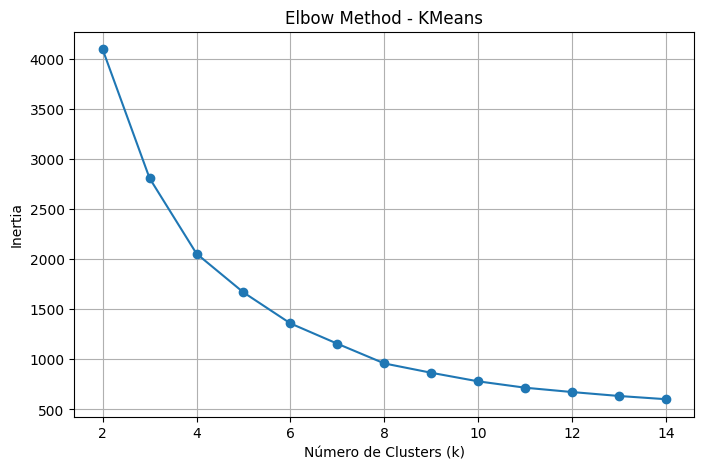

In [ ]:
####################################################################################

#     AVALIANDO KMEANS - ELBOW METHOD

####################################################################################


''' 

Procurar o ponto onde a curva deixa de cair drasticamente e começa a “achatar”. Esse é o k ideal.

Ajuda a verificar a inércia. No K-Means inércia é a soma das distâncias ao quadrado de cada ponto até o centróide do seu cluster (ex: 1^2 + 2^2 + 3^2).
Quanto menor a inércia, mais próximos os pontos estão do centro do grupo, ao aumentar o número de clusters a inércia sempre diminui o problema 
é que depois de certo ponto essa redução passa a ser irrelevante.

'''

import matplotlib.pyplot as plt

# Defina o intervalo de clusters que deseja testar

inercia = []
grupos_possiveis = range(2, 15)
k_grupos = grupos_possiveis

for k in k_grupos:
    kmeans2 = KMeans(
        n_clusters= k,
        random_state= 42,
        n_init=10)
    kmeans2.fit(x_scaled)
    inercia.append(kmeans2.inertia_)


# Plot do Elbow Method
plt.figure(figsize=(8, 5))
plt.plot(k_grupos, inercia, marker='o')
plt.xlabel('Número de Clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method - KMeans')
plt.grid(True)
plt.show()

                 qtd_registros  percentual_%
cluster_produto                             
0                          657         54.39
1                          385         31.87
2                          149         12.33
3                           17          1.41


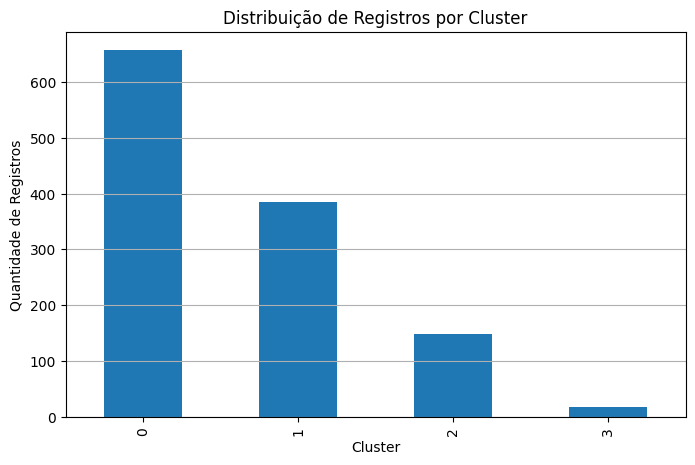

In [7]:
####################################################################################

#     AVALIANDO KMEANS - TAMANHO E BALANCEAMENTO DOS CLUSTERS

####################################################################################


''' 

AVALIAR AS QUESTÕES:
Existe cluster com < 5% dos dados?
Existe cluster com > 50 ou 60% dos dados?
Os clusters têm tamanhos razoavelmente comparáveis?
Os clusters pequenos fazem sentido como segmentos específicos?
O modelo KMEANS não exige clusters do mesmo tamanho, mas se existir um desequilíbrio extremo é problema.

'''


# Contagem absoluta por cluster
cluster_tamanho = base_modelo_agregado["cluster_produto"].value_counts().sort_index()

# Percentual por cluster
cluster_percent = (cluster_tamanho / len(base_modelo_agregado)) * 100

# DataFrame resumo
cluster_summary = pd.DataFrame({
    'qtd_registros': cluster_tamanho,
    'percentual_%': cluster_percent.round(2)})
print(cluster_summary)


################################
# PLOTANDO GRAFICO


plt.figure(figsize=(8, 5))
cluster_tamanho.plot(kind='bar')
plt.xlabel('Cluster')
plt.ylabel('Quantidade de Registros')
plt.title('Distribuição de Registros por Cluster')
plt.grid(axis='y')
plt.show()

In [ ]:
####################################################################################

#     AVALIANDO KMEANS - ESTABILIDADE DOS CLUSTERS (SEED / AMOSTRAGEM)

####################################################################################


''' 

Nesta validação procuramos responder a seguinte pergunta:
Os clusters que eu encontrei são reais ou são só um acaso do algoritmo/dos dados?

O ARI mede o quanto duas clusterizações são iguais, corrigindo o acaso e o KMEANS precisa dessa validação porque ele não descobre verdade absoluta, ele começa com 
centróides aleatórios (seed), muda o grupo se os dados mudarem um pouco e sempre força alguém a entrar em um cluster.

    #SEED
    Se eu rodar o algoritmo de novo, ele encontra a mesma estrutura?

    #AMOSTRAGEM
    Se eu tirar ou trocar algumas observações, a estrutura continua?

ARI médio próximo de 1 → clusters estáveis
                    0.0 → parecido com aleatório
                    < 0 → pior que aleatório
ARI baixo ou desvio padrão alto → clusters sensíveis a seed ou dados

'''

from sklearn.metrics import adjusted_rand_score
from sklearn.utils import resample


### definido o centro
centroides = kmeans.cluster_centers_

### definindo as colunas
labels_base = kmeans_com_silhouette.labels_

#### Reatribuição em amostras (Retreinando o modelo existente para garantir variação)

def estabilidade_kmeans(x_scaled, k, labels_base, n_iter=42, frac=0.8):
    scores = []

    for i in range(n_iter):
        idx = resample(
            np.arange(len(x_scaled)),
            replace=False,
            n_samples=int(len(x_scaled) * frac),
            random_state=i)
        X_sample = x_scaled[idx]

        #### RE-TREINA o KMeans (agora sim varia!)
        kmeans_i = KMeans(
            n_clusters=k,
            random_state=i,
            n_init=10)
        kmeans_i.fit(X_sample)

        labels_sample = kmeans_i.labels_

        score = adjusted_rand_score(
            labels_base[idx],
            labels_sample)
        scores.append(score)

    return np.mean(scores), np.std(scores)


## resultados
media, desvio = estabilidade_kmeans(
    x_scaled=x_scaled,
    k=kmeans_com_silhouette.n_clusters,
    labels_base=kmeans_com_silhouette.labels_)

print("ARI médio:", media)
print("Desvio padrão:", desvio)

ARI médio: 0.9505017635086727
Desvio padrão: 0.10620346836873684


In [9]:
####################################################################################

#     AVALIANDO KMEANS - ROBUSTEZ AO LONGO DO TEMPO

####################################################################################

''' 

O objetivo é responder à pergunta: os clusters continuam fazendo sentido quando o tempo passa ou eles “quebram”?

METODOLOGIA
Escolhe um período base (ex: anos iniciais)
Treina o KMeans apenas nesse período
Usa os mesmos centróides para prever clusters nos períodos seguintes
Mede a consistência temporal das atribuições (ARI)
Não re-treina o modelo ao longo do tempo

Os clusters mudam muito ao longo do tempo ? será que eles estão aumentando ou diminuindo ?
Precisamos encontrar uma certa normalidade nos percentuais dos grupos

'''


##################
## Separar período base e períodos futuros
periodo_anterior = base_modelo_agregado["ANO"] <= 2018


##################
## Treinar KMeans apenas no período anterior
kmeans_periodo_anterior = KMeans(
    n_clusters=melhor_numero,
    random_state=42,
    n_init=10)

# aplicar o kmeans na base anterior
kmeans_periodo_anterior.fit(x_scaled[periodo_anterior])
labels_base_anterior = kmeans_periodo_anterior.labels_


##################
## Validação temporal (robustez ao longo do tempo)
def validacao_temporal_kmeans(x_scaled, base_usada, kmeans_model, col_tempo, ano_base):
    resultados = []
    anos = sorted(base_modelo_agregado[col_tempo].unique())
    for ano in anos:
        if ano <= ano_base:
            continue 
        idx_ano = base_modelo_agregado[col_tempo] == ano
        labels_ano = kmeans_model.predict(x_scaled[idx_ano])

        # contando os grupos e armazenando no dicionario vazio
        dist = np.round(np.bincount(
            labels_ano,
            minlength=kmeans_model.n_clusters) / len(labels_ano)*100,2)

        resultados.append({"ANO": ano, "QTD_CLUSTERS": dist})

    return pd.DataFrame(resultados)

##################
## Rodar a validação temporal

#CHAMANDO A FUNÇÃO CRIADA ACIMA
resultados_temporais = validacao_temporal_kmeans(
    x_scaled=x_scaled,
    base_usada=base_modelo_agregado,
    kmeans_model=kmeans_periodo_anterior,
    col_tempo="ANO",
    ano_base=2018)

# copia os dados para uma nova variavel
resultados_temporais_nome = resultados_temporais.copy()

# pivota dicionario em um dataframe para linhas e colunas
clusters_df = pd.DataFrame(resultados_temporais_nome["QTD_CLUSTERS"].to_list(),
    columns=[f"cluster_{i} (%)" for i in range(len(resultados_temporais_nome["QTD_CLUSTERS"].iloc[0]))])

# relaciona o que a função gerou com o datframe pivotado pela coluna de ANO 
resultados_temporais_final = pd.concat([resultados_temporais_nome[["ANO"]], clusters_df], axis=1)
print(resultados_temporais_final)



    ANO  cluster_0 (%)  cluster_1 (%)  cluster_2 (%)  cluster_3 (%)
0  2019          15.62          56.25          26.56           1.56
1  2020          17.19          57.81          23.44           1.56
2  2021          18.03          54.10          26.23           1.64
3  2022          22.58          53.23          22.58           1.61


In [10]:
####################################################################################

#     AVALIANDO KMEANS - ANALISE OUTLIERS RUIDO

####################################################################################


''' 

OUTLIERS PERCENTIL: 
diz que qualquer ponto que esteja nos 5% mais distantes do centro (independente do cluster) é um outlier.
não importa a distância real, eu vou marcar como outlier os 5% que estiverem mais longe de seus centros.É uma medida de ranking, pois se todos os pontos 
estivessem muito perto dos centros, ele ainda assim pegaria os 5% "menos perto" e chamaria de outlier.

OUTLIERS MAD:
olha para a mediana das distâncias. O critério > 3 é similar a dizer que o ponto está a mais de 3 "desvios" da normalidade
Se o outliers_mad é alto, significa que esses pontos estão muito longe do que é considerado o comportamento padrão daquele grupo

DISTANCIA MEDIA CENTROIDE: Quanto menor, melhor. Indica que, em média, os produtos estão perto do "centro" do perfil

'''

from scipy.spatial.distance import cdist
from scipy.stats import median_abs_deviation


##################
## Distância de cada ponto ao centróide
centroids = kmeans_com_silhouette.cluster_centers_
distancias_centroides = np.min(cdist(x_scaled, centroids, metric="euclidean"), axis=1)
df_validacao = pd.DataFrame({"cluster": labels_base, "distancia_centroide": distancias_centroides})



##################
## Outliers Percentil
limite_percentil = np.percentile(distancias_centroides, 95)
df_validacao["outlier_percentil"] = (df_validacao["distancia_centroide"] > limite_percentil)



##################
## Outliers MAD (Median Absolute Deviation)
mediana = np.median(distancias_centroides)
mad = median_abs_deviation(distancias_centroides)
df_validacao["outlier_mad"] = (np.abs(distancias_centroides - mediana) / mad > 3)



##################
## Análise final
resumo = (
    df_validacao
    .groupby("cluster")
    .agg(total_pontos=("distancia_centroide", "count"),
        outliers_percentil=("outlier_percentil", "sum"),
        outliers_mad=("outlier_mad", "sum"),
        distancia_media=("distancia_centroide", "mean"),
        distancia_max=("distancia_centroide", "max")))

resumo.head()


,total_pontos,outliers_percentil,outliers_mad,distancia_media,distancia_max
cluster,,,,,
0,657,46,57,1.26,3.54
1,385,0,1,0.97,2.24
2,149,15,17,1.45,3.12
3,17,0,0,0.60,1.25


In [23]:
####################################################################################

#     AVALIANDO KMEANS - INTERPRETABILIDADE DE CLUSTERS ( PERFIL MEDIO POR CLUSTER)

####################################################################################



''' 
Validação de perfil_medio para características típicas de cada cluster
Validação de tamanho para relevância de cada grupo
Validação de desvio para consistência interna do cluster
Validação de normalizado para diferenciação entre clusters


Com estas validações buscamos responder as seguintes perguntas:
O que carcateriza cada cluster ? (neste o estoque e as vendas são maiores, neste outro grupo as vendas são menores)
Os cluster são realmente diferentes entre si ?
Cada cluster é internamente consistente ? os itens dentro do grupo são parecidos entre si ? (desvio padrão)
Qual cluster importa mais ? (qual grupo concentra a maior quantidade de individuos e o que posso fazer por eles)
Consigo dar um nome para o cluster ? (exemplo, grupo 1 são os que movimentam menos, grupo 2 os que movimentam mais)

Com cada uma destas perguntas respondidas conseguimos atuar de forma mais assertiva com plano de ação para cada grupo/cluster

'''



##################
## PERFIL MÉDIO POR CLUSTER (CENTROIDES REAIS)

##perfil_medio = (base_modelo_agregado.groupby('cluster_produto').mean().round(2))
perfil_medio = (
    base_modelo_agregado.groupby('cluster_produto').agg(tu_media=('tu_media', 'mean'),
        tu_std=('tu_std', 'std'),
        tu_min=('tu_min', 'min'),
        tu_max=('tu_max', 'max'),
        n_registros=('n_registros', 'count')))

print('##############################')
print("(O que carcateriza cada cluster) Valores médios reais por cluster:")
display(perfil_medio)



##################
## TAMANHO DOS CLUSTERS

tamanho_clusters = (base_modelo_agregado['cluster_produto'].value_counts().sort_index().rename('qtd_registros'))
print('##############################')
print("\n(Os cluster são realmente diferentes entre si) Tamanho dos clusters:")
display(tamanho_clusters)



##################
## PERFIL NORMALIZADO (Ajuda a observar quem está acima/abaixo da média geral)

media_geral = base_modelo_agregado.drop(columns='cluster_produto').mean()
perfil_normalizado = ( perfil_medio.sub(media_geral).div(media_geral).round(2).dropna(axis=1, how='all'))
print('##############################')
print("\n(diferenciação entre clusters) Valores normalizados (escala):")
display(perfil_normalizado)


##############################
(O que carcateriza cada cluster) Valores médios reais por cluster:


,tu_media,tu_std,tu_min,tu_max,n_registros
cluster_produto,,,,,
0,3.96,0.10,3.00,6.03,657
1,3.41,0.11,3.00,4.48,385
2,4.32,0.10,3.32,5.38,149
3,4.97,0.04,3.00,7.14,17


##############################

(Os cluster são realmente diferentes entre si) Tamanho dos clusters:


cluster_produto
0    657
1    385
2    149
3     17
Name: qtd_registros, dtype: int64

##############################

(diferenciação entre clusters) Valores normalizados (escala):


,n_registros,tu_max,tu_media,tu_min,tu_std
cluster_produto,,,,,
0,6.27,0.35,0.03,-0.06,-0.72
1,3.26,-0.00,-0.11,-0.06,-0.68
2,0.65,0.20,0.12,0.04,-0.71
3,-0.81,0.59,0.29,-0.06,-0.90


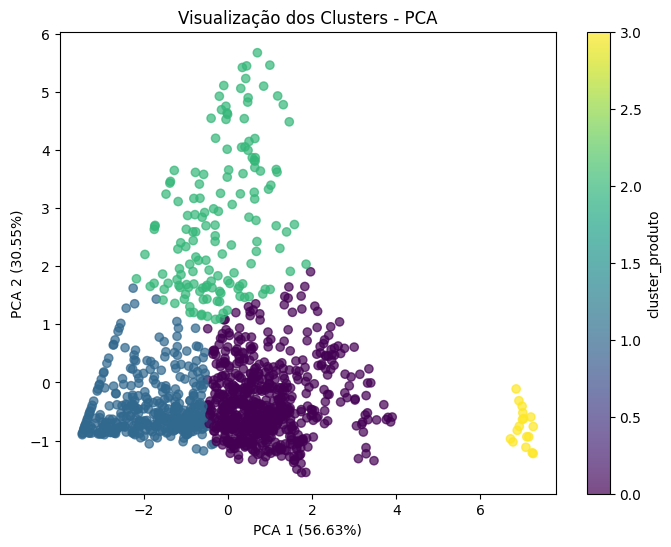

c:\Users\Guilh\AppData\Local\Programs\Python\Python313\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


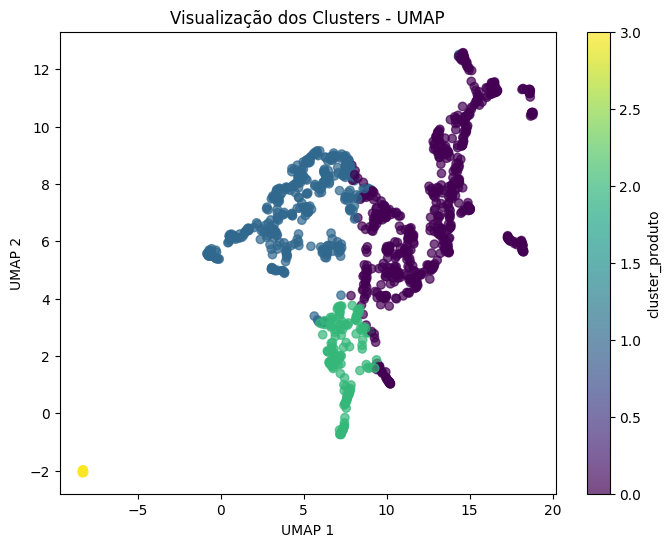

In [13]:
####################################################################################

#     AVALIANDO KMEANS - VISUALIZAÇÃO DOS CLUSTERS (PCA / UMAP)

####################################################################################



''' 

# PCA: 
ajuda a avaliar se os clusters são linearmente separáveis, o quanto da variância total está sendo explicada e se há sobreposição forte entre clusters.

# UMAP: 
ajuda a avaliar se existe estrutura não linear, se o KMeans está capturando padrões reais e a clareza visual de separação dos grupos.



'''
## pip install umap-learn
from sklearn.decomposition import PCA
import umap


##################
## PCA REDUÇÃO PARA 2 DIMENSÕES

pca = PCA(n_components=2, random_state=42)
x_pca = pca.fit_transform(x_scaled)

df_pca = pd.DataFrame(
    x_pca,
    columns=['PCA_1', 'PCA_2']
)

df_pca['cluster'] = base_modelo_agregado['cluster_produto'].values

## VISUALIZAÇÃO PCA
plt.figure(figsize=(8, 6))
plt.scatter(
    df_pca['PCA_1'],
    df_pca['PCA_2'],
    c=df_pca['cluster'],
    alpha=0.7
)
plt.title('Visualização dos Clusters - PCA')
plt.xlabel(f'PCA 1 ({pca.explained_variance_ratio_[0]:.2%})')
plt.ylabel(f'PCA 2 ({pca.explained_variance_ratio_[1]:.2%})')
plt.colorbar(label='cluster_produto')
plt.show()



##################
## UMAP REDUÇÃO NÃO LINEAR

umap_model = umap.UMAP(
    n_components=2,
    n_neighbors=15,
    min_dist=0.1,
    random_state=42
)

x_umap = umap_model.fit_transform(x_scaled)

df_umap = pd.DataFrame(
    x_umap,
    columns=['UMAP_1', 'UMAP_2']
)

df_umap['cluster'] = base_modelo_agregado['cluster_produto'].values

## VISUALIZAÇÃO UMAP
plt.figure(figsize=(8, 6))
plt.scatter(
    df_umap['UMAP_1'],
    df_umap['UMAP_2'],
    c=df_umap['cluster'],
    alpha=0.7
)
plt.title('Visualização dos Clusters - UMAP')
plt.xlabel('UMAP 1')
plt.ylabel('UMAP 2')
plt.colorbar(label='cluster_produto')
plt.show()




In [ ]:
####################################################################################

#     AVALIANDO KMEANS - ADERÊNCIA AOS OBJETIVOS DO NEGÓCIO

####################################################################################


''' 

OBJETIVO: Utilizar KMEANS para gerar cluster de produtos e enriquecer a base do modelo de RANDONFORESTREGRESSOR (Feature Engineering)


RESULTADO: Coerente com o objetivo desejado, abaixo trago anotações de cada validação realizada no modelo.

    Modelo criado com silhouette_score
    Elbow Method com queda forte até k ≈ 4, indica que adicionar clusters nesse intervalo melhora a explicação dos dados

    Contem um desbalanceamento entre os grupos pois 86% dos dados estão entre os clusters 0 e 1. O grupo 2 me parece estável, porém no cluster 3 ele separou um pequeno grupo 
    que podem ser outliers.

    ARI médio ≈ 0.95 significa que as clusterizações obtidas em diferentes amostras são quase idênticas, ou seja, o K-Means está encontrando os mesmos grupos, mesmo quando parte dos 
    dados muda. Com desvio padrão ≈ 0.10 significa que a variação é pequena, isso é algo bom.

    As proporções por cluster mudam pouco de 2019 a 2022,nenhum cluster aparece ou desaparece ao longo dos anos. O grupo
    0(zero) cresce pois varia de 15%-23% e indica transição gradual de comportamento ou mudança real no mix (ex: produtos migrando de perfil) mas com crescimento suave, 
    não abrupto o que indica um  modelo robusto

    A análise de outliers indica que o K-Means produziu clusters internamente consistentes, com maior presença de ruído apenas nos grupos grandes que é o esperado deles.
    Os clusters apresentam perfis médios claramente diferenciados em relação à variável TU, a segmentação está interpretável, consistente e alinhada com as demais validações do modelo.

    PCA - Clusters alongados e não esféricos, especialmente o cluster verde (2), com grande variação em PCA 2. A visualização em PCA indica que o K-Means capturou 
    corretamente a estrutura global dos dados, com clara separação de um cluster extremo e transições graduais entre os demais segmentos. Apesar de 
    alguma sobreposição entre clusters centrais, a segmentação é consistente, estável e interpretável, sendo adequada ao objetivo analítico proposto que é segmentação.

    UMAP - Os clusters aparecem bem segmentados visualmente, temos regiões densas dominadas por uma única cor, pouca sobreposição direta entre cores diferentes. 
    O ponto de atenção é a estrutura não esférica pois o K-Means assume clusters aproximadamente esféricos e separados por distância euclidiana. O UMAP confirma que os 
    clusters do K-Means representam grupos estruturalmente distintos, com boa coerência local, entretanto, a geometria não esférica dos grupos e a presença de um cluster 
    extremamente pequeno indicam que o K-Means é adequado, mas não ótimo, especialmente para capturar padrões complexos e outliers.

'''